In [18]:
# ─────────────────────────────────────────────
# LIBRAIRIES
# ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import polars.selectors as cs
from pathlib import Path

plt.rcParams["font.size"] = 16

# ─────────────────────────────────────────────
# ROOT
# ─────────────────────────────────────────────
root  = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-06-19")
paths = [str(p) for p in root.glob("nucleo__*")]

# ─────────────────────────────────────────────
# PARAMETRES DE FILTRAGE
# ─────────────────────────────────────────────
s       = 150
mu      = 160
ls      = [10, 50, 100]
thetas  = [20, 60]
bpmins  = [0, 5, 10, 15, 20]
ylims   = [-50, 500]

# ─────────────────────────────────────────────
# CHARGEMENT DES DONNEES
# ─────────────────────────────────────────────

ARRAY_COLS = []

df_periodic = (
    pl.scan_parquet(paths)
    .filter(
        (pl.col("s")     == s) &
        (pl.col("theta").is_in(thetas)) &
        (pl.col("l").is_in(ls))
    )
    .select(cs.numeric() | cs.boolean() | cs.string() | cs.by_name(*ARRAY_COLS))
    .collect()
    .sort(["land", "bpmin", "l", "mu"])
    .filter(
    (pl.col("land") == "periodic") &
    (pl.col("bpmin") == 0)
    )
)

groups = (
    df_periodic
    .group_by(["theta", "l"])
    .agg([
        pl.col("mu"),
        pl.col("vf")
    ])
    .sort(["theta", "l"])
)

colors = {
    10: "C0",
    50: "C1",
    100: "C2",
}

linestyles = {
    20: "-",
    60: "--",
}

plt.figure(figsize=(8, 6), dpi=1200)

for row in groups.iter_rows(named=True):
    theta = row["theta"]
    l = row["l"]

    mu_vals = np.array(row["mu"])
    vf_vals = np.array(row["vf"])

    idx = np.argsort(mu_vals)
    mu_vals = mu_vals[idx]
    vf_vals = vf_vals[idx]

    plt.plot(
        mu_vals,
        vf_vals,
        color=colors[l],
        linestyle=linestyles[theta],
        lw=2.5,
        label=rf"$l={l},\ \theta={theta}$",
    )

plt.grid(alpha=0.3)
plt.xlabel(r"$\mu$")
plt.ylabel(r"$v_{init}$")
plt.ylim(ylims)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

In [19]:
# ─────────────────────────────────────────────
# LIBRAIRIES
# ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import polars.selectors as cs
from pathlib import Path

plt.rcParams["font.size"] = 16

# ─────────────────────────────────────────────
# ROOT
# ─────────────────────────────────────────────
root  = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-06-19")
paths = [str(p) for p in root.glob("nucleo__*")]

# ─────────────────────────────────────────────
# PARAMETRES DE FILTRAGE
# ─────────────────────────────────────────────
s       = 150
mu      = 160
ls      = [10, 50, 100]
thetas  = [20, 60]
bpmins  = [0, 5, 10, 15, 20]
ylims   = [-50, 500]

# ─────────────────────────────────────────────
# CHARGEMENT DES DONNEES
# ─────────────────────────────────────────────

ARRAY_COLS = []

df_random = (
    pl.scan_parquet(paths)
    .filter(
        (pl.col("s")     == s) &
        (pl.col("theta").is_in(thetas)) &
        (pl.col("l").is_in(ls))
    )
    .select(cs.numeric() | cs.boolean() | cs.string() | cs.by_name(*ARRAY_COLS))
    .collect()
    .sort(["land", "bpmin", "l", "mu"])
    .filter(
    (pl.col("land") == "random") &
    (pl.col("bpmin") == 0)
    )
)

groups = (
    df_random
    .group_by(["theta", "l"])
    .agg([
        pl.col("mu"),
        pl.col("vf")
    ])
    .sort(["theta", "l"])
)

colors = {
    10: "C0",
    50: "C1",
    100: "C2",
}

linestyles = {
    20: "-",
    60: "--",
}

plt.figure(figsize=(8, 6), dpi=1200)

for row in groups.iter_rows(named=True):
    theta = row["theta"]
    l = row["l"]

    mu_vals = np.array(row["mu"])
    vf_vals = np.array(row["vf"])

    idx = np.argsort(mu_vals)
    mu_vals = mu_vals[idx]
    vf_vals = vf_vals[idx]

    plt.plot(
        mu_vals,
        vf_vals,
        color=colors[l],
        linestyle=linestyles[theta],
        lw=2.5,
        label=rf"$l={l},\ \theta={theta}$",
    )

plt.grid(alpha=0.3)
plt.xlabel(r"$\mu$")
plt.ylabel(r"$v_{init}$")
plt.ylim(ylims)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

In [25]:
# ─────────────────────────────────────────────
# LIBRAIRIES
# ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import polars.selectors as cs
from pathlib import Path

plt.rcParams["font.size"] = 16

# ─────────────────────────────────────────────
# ROOT
# ─────────────────────────────────────────────
root  = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-06-19")
paths = [str(p) for p in root.glob("nucleo__*")]

# ─────────────────────────────────────────────
# PARAMETRES DE FILTRAGE
# ─────────────────────────────────────────────
s       = 150
mu      = 160
ls      = [10]
thetas  = [20, 60]
bpmins  = [0, 5, 10, 15]
ylims   = [-50, 500]

# ─────────────────────────────────────────────
# CHARGEMENT DES DONNEES
# ─────────────────────────────────────────────

ARRAY_COLS = []

df_bpmin = (
    pl.scan_parquet(paths)
    .filter(
        (pl.col("s")     == s) &
        (pl.col("theta").is_in(thetas)) &
        (pl.col("l").is_in(ls))
    )
    .select(cs.numeric() | cs.boolean() | cs.string() | cs.by_name(*ARRAY_COLS))
    .collect()
    .sort(["land", "bpmin", "l", "mu"])
    .filter(
    (pl.col("land") == "random") &
    (pl.col("bpmin").is_in(bpmins))
    )
)

groups = (
    df_bpmin
    .group_by(["theta", "bpmin"])
    .agg([
        pl.col("mu"),
        pl.col("vf")
    ])
    .sort(["theta", "bpmin"])
)

colors = {
    0: "C0",
    5: "C1",
    10: "C2",
    15: "C3",
}

linestyles = {
    20: "-",
    60: "--",
}

plt.figure(figsize=(8, 6), dpi=1200)

for row in groups.iter_rows(named=True):
    theta = row["theta"]
    bpmin = row["bpmin"]

    mu_vals = np.array(row["mu"])
    vf_vals = np.array(row["vf"])

    idx = np.argsort(mu_vals)
    mu_vals = mu_vals[idx]
    vf_vals = vf_vals[idx]

    plt.plot(
        mu_vals,
        vf_vals,
        color=colors[bpmin],
        linestyle=linestyles[theta],
        lw=2.5,
        label=rf"$bpmin={bpmin},\ \theta={theta}$",
    )

plt.grid(alpha=0.3)
plt.xlabel(r"$\mu$")
plt.ylabel(r"$v_{init}$")
plt.ylim(ylims)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

In [2]:
# ─────────────────────────────────────────────
# LIBRAIRIES
# ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import polars.selectors as cs
from pathlib import Path

plt.rcParams["font.size"] = 16

# ─────────────────────────────────────────────
# ROOT
# ─────────────────────────────────────────────
root  = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-06-19")
paths = [str(p) for p in root.glob("nucleo__*")]

# ─────────────────────────────────────────────
# PARAMETRES
# ─────────────────────────────────────────────
s = 150
theta = 20

# configs à comparer
configs = [
    (10, 0),
    (100, 0),
    (10, 15),
]

colors = {
    (10, 0):  "C0",
    (100, 0): "C1",
    (10, 15): "C2",
}

# ─────────────────────────────────────────────
# CHARGEMENT DES DONNEES
# ─────────────────────────────────────────────

ARRAY_COLS = ["l_view"]

df_view = (
    pl.scan_parquet(paths)
    .filter(
        (pl.col("s") == s) &
        (pl.col("theta") == theta) &
        (pl.col("l").is_in([10, 100])) &
        (pl.col("bpmin").is_in([0, 15])) &
        (pl.col("land") == "random")
    )
    .select(cs.numeric() | cs.boolean() | cs.string() | cs.by_name(*ARRAY_COLS))
    .collect()
)

# ─────────────────────────────────────────────
# PLOT LINK VIEW
# ─────────────────────────────────────────────

plt.figure(figsize=(8, 6), dpi=1200)

groups = df_view.group_by(["l", "bpmin"]).agg([
    pl.col("l_view")
])

for row in groups.iter_rows(named=True):
    l = row["l"]
    bpmin = row["bpmin"]

    if (l, bpmin) not in colors:
        continue

    link_view = np.mean(np.array(row["l_view"]), axis=0)
    x = np.arange(len(link_view))

    plt.plot(
        x,
        link_view,
        lw=2.5,
        color=colors[(l, bpmin)],
        label=rf"$l={l},\ bpmin={bpmin}$"
    )

plt.grid(alpha=0.3)
plt.xlabel("Position")
plt.ylabel("")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ─────────────────────────────────────────────
# LIBRAIRIES
# ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import polars.selectors as cs
from pathlib import Path

plt.rcParams["font.size"] = 16

# ─────────────────────────────────────────────
# ROOT
# ─────────────────────────────────────────────
root  = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-06-19")
paths = [str(p) for p in root.glob("nucleo__*")]

# ─────────────────────────────────────────────
# PARAMETRES DE FILTRAGE
# ─────────────────────────────────────────────
s       = 150
mu      = 160
ls      = [10, 50, 100]
thetas  = [20, 60]
bpmins  = [0, 5, 10, 15, 20]
ylims   = [-0.10, 1.10]

# ─────────────────────────────────────────────
# CHARGEMENT DES DONNEES
# ─────────────────────────────────────────────

ARRAY_COLS = []

df_random = (
    pl.scan_parquet(paths)
    .filter(
        (pl.col("s")     == s) &
        (pl.col("theta").is_in(thetas)) &
        (pl.col("l").is_in(ls))
    )
    .select(cs.numeric() | cs.boolean() | cs.string() | cs.by_name(*ARRAY_COLS))
    .collect()
    .sort(["land", "bpmin", "l", "mu"])
    .filter(
    (pl.col("land") == "random") &
    (pl.col("bpmin") == 0)
    )
)

groups = (
    df_random
    .group_by(["theta", "l"])
    .agg([
        pl.col("mu"),
        pl.col("wf")
    ])
    .sort(["theta", "l"])
)

colors = {
    10: "C0",
    50: "C1",
    100: "C2",
}

linestyles = {
    20: "-",
    60: "--",
}

plt.figure(figsize=(8, 6), dpi=1200)

for row in groups.iter_rows(named=True):
    theta = row["theta"]
    l = row["l"]

    mu_vals = np.array(row["mu"])
    wf_vals = np.array(row["wf"])

    idx = np.argsort(mu_vals)
    mu_vals = mu_vals[idx]
    wf_vals = wf_vals[idx]

    plt.plot(
        mu_vals,
        wf_vals,
        color=colors[l],
        linestyle=linestyles[theta],
        lw=2.5,
        label=rf"$l={l},\ \theta={theta}$",
    )

plt.grid(alpha=0.3)
plt.xlabel(r"$\mu$")
plt.ylabel(r"$w_{f}$")
plt.ylim(ylims)
plt.legend(ncol=2)
plt.title("Random")
plt.tight_layout()
plt.show()

In [ ]:
# ─────────────────────────────────────────────
# LIBRAIRIES
# ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import polars.selectors as cs
from pathlib import Path

plt.rcParams["font.size"] = 16

# ─────────────────────────────────────────────
# ROOT
# ─────────────────────────────────────────────
root  = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-06-19")
paths = [str(p) for p in root.glob("nucleo__*")]

# ─────────────────────────────────────────────
# PARAMETRES DE FILTRAGE
# ─────────────────────────────────────────────
s       = 150
mu      = 160
ls      = [10]
thetas  = [20, 60]
bpmins  = [0, 15]
ylims   = [-0.10, 1.10]

# ─────────────────────────────────────────────
# CHARGEMENT DES DONNEES
# ─────────────────────────────────────────────

ARRAY_COLS = []

df_bpmin = (
    pl.scan_parquet(paths)
    .filter(
        (pl.col("s")     == s) &
        (pl.col("theta").is_in(thetas)) &
        (pl.col("l").is_in(ls))
    )
    .select(cs.numeric() | cs.boolean() | cs.string() | cs.by_name(*ARRAY_COLS))
    .collect()
    .sort(["land", "bpmin", "l", "mu"])
    .filter(
    (pl.col("land") == "random") &
    (pl.col("bpmin").is_in(bpmins))
    )
)

groups = (
    df_bpmin
    .group_by(["theta", "bpmin"])
    .agg([
        pl.col("mu"),
        pl.col("wf")
    ])
    .sort(["theta", "bpmin"])
)

colors = {
    0: "C0",
    5: "C1",
    10: "C2",
    15: "C3",
}

linestyles = {
    20: "-",
    60: "--",
}

plt.figure(figsize=(8, 6), dpi=1200)

for row in groups.iter_rows(named=True):
    theta = row["theta"]
    bpmin = row["bpmin"]

    mu_vals = np.array(row["mu"])
    wf_vals = np.array(row["wf"])

    idx = np.argsort(mu_vals)
    mu_vals = mu_vals[idx]
    wf_vals = wf_vals[idx]

    plt.plot(
        mu_vals,
        wf_vals,
        color=colors[bpmin],
        linestyle=linestyles[theta],
        lw=2.5,
        label=rf"$bpmin={bpmin},\ \theta={theta}$",
    )

plt.grid(alpha=0.3)
plt.xlabel(r"$\mu$")
plt.ylabel(r"$w_{f}$")
plt.ylim(ylims)
plt.legend(ncol=2)
plt.title("Bpmin")
plt.tight_layout()
plt.show()

# FIGURE 4

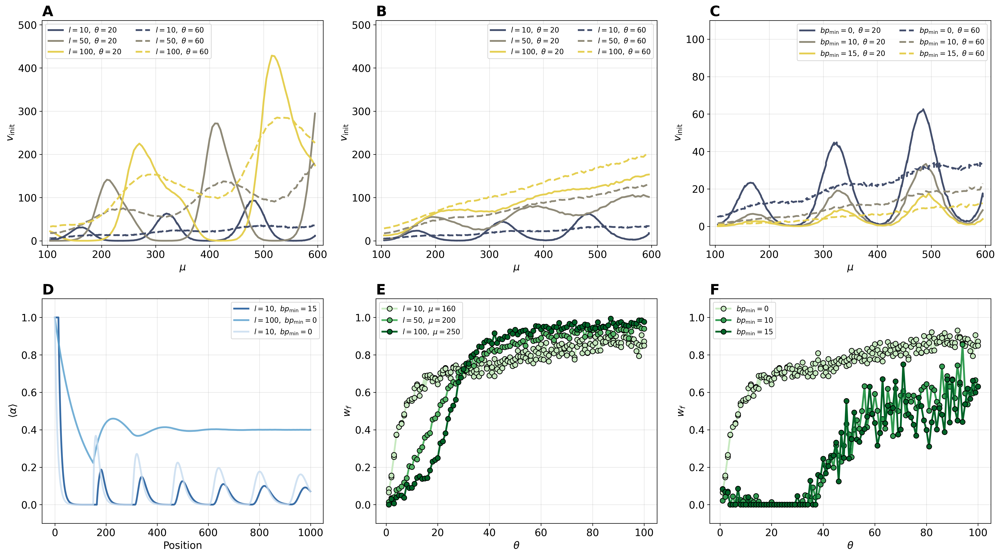

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import polars.selectors as cs
from pathlib import Path

plt.rcParams["font.size"] = 14

# ─────────────────────────────────────────────
# ROOTS
# ─────────────────────────────────────────────
root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/MAIN_PARQUET")
path = root / "ncl_output.parquet"          # <- Path / str, pas Path + str

root_D = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/FIGURE_5__PC__2026-09-27")
paths_D = [str(p) for p in root_D.rglob("*.parquet")]


# ─────────────────────────────────────────────
# FIGURE
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 11), dpi=300)
(ax_A1, ax_A2, ax_A3), (ax_B1, ax_B2, ax_B3) = axes
xlims_A = [90, 610]
xticks_A = [100, 200, 300, 400, 500, 600]

# ═══════════════════════════════════════════════════════════════════════════
# A1 : vf vs mu — landscape periodic, bpmin=0, l ∈ {10,50,100} (cellule 0)
# ═══════════════════════════════════════════════════════════════════════════
s_A1, ls_A1, thetas_A1 = 150, [10, 50, 100], [20, 60]
ylims_A1 = [-10, 510]

df_A1 = (
    pl.scan_parquet(path)
    .filter(
        (pl.col("s") == s_A1) &
        (pl.col("theta").is_in(thetas_A1)) &
        (pl.col("l").is_in(ls_A1))
    )
    .select(cs.numeric() | cs.boolean() | cs.string())
    .collect()
    .sort(["land", "bpmin", "l", "mu"])
    .filter((pl.col("land") == "periodic") & (pl.col("bpmin") == 0))
)

groups_A1 = (
    df_A1.group_by(["theta", "l"]).agg([pl.col("mu"), pl.col("vf")]).sort(["theta", "l"])
)

cividis = plt.cm.cividis(np.linspace(0.25, 0.9, len(ls_A1)))

colors_A1 = {
    l: color for l, color in zip(ls_A1, cividis)
}
linestyles_A1 = {20: "-", 60: "--"}

for row in groups_A1.iter_rows(named=True):
    theta, l = row["theta"], row["l"]
    mu_vals = np.array(row["mu"])
    vf_vals = np.array(row["vf"])
    idx = np.argsort(mu_vals)
    mu_vals, vf_vals = mu_vals[idx], vf_vals[idx]

    ax_A1.plot(
        mu_vals[(mu_vals>100) & (mu_vals<600)], vf_vals[(mu_vals>100) & (mu_vals<600)],  # Limite l'affichage à [100, 600] pour éviter les valeurs extrêmes
        color=colors_A1[l], linestyle=linestyles_A1[theta], lw=2.5,
        label=rf"$l={l},\ \theta={theta}$",
    )

ax_A1.grid(alpha=0.3)
ax_A1.set_xlabel(r"$\mu$")
ax_A1.set_ylabel(r"$v_{\text{init}}$")
ax_A1.set_xlim(xlims_A)
ax_A1.set_xticks(xticks_A)
ax_A1.set_ylim(ylims_A1)
ax_A1.legend(ncol=2, fontsize=10)

# ═══════════════════════════════════════════════════════════════════════════
# A2 : vf vs mu — landscape random, bpmin=0, l ∈ {10,50,100} (cellule 1)
# ═══════════════════════════════════════════════════════════════════════════
s_A2, ls_A2, thetas_A2 = 150, [10, 50, 100], [20, 60]
ylims_A2 = ylims_A1

df_A2 = (
    pl.scan_parquet(path)
    .filter(
        (pl.col("s") == s_A2) &
        (pl.col("theta").is_in(thetas_A2)) &
        (pl.col("l").is_in(ls_A2))
    )
    .select(cs.numeric() | cs.boolean() | cs.string())
    .collect()
    .sort(["land", "bpmin", "l", "mu"])
    .filter((pl.col("land") == "random") & (pl.col("bpmin") == 0))
)

groups_A2 = (
    df_A2.group_by(["theta", "l"]).agg([pl.col("mu"), pl.col("vf")]).sort(["theta", "l"])
)

colors_A2 = {
    l: color for l, color in zip(ls_A2, cividis)
}
linestyles_A2 = {20: "-", 60: "--"}

for row in groups_A2.iter_rows(named=True):
    theta, l = row["theta"], row["l"]
    mu_vals = np.array(row["mu"])
    vf_vals = np.array(row["vf"])
    idx = np.argsort(mu_vals)
    mu_vals, vf_vals = mu_vals[idx], vf_vals[idx]

    ax_A2.plot(
        mu_vals[(mu_vals>100) & (mu_vals<600)], vf_vals[(mu_vals>100) & (mu_vals<600)],  # Limite l'affichage à [100, 600] pour éviter les valeurs extrêmes
        color=colors_A2[l], linestyle=linestyles_A2[theta], lw=2.5,
        label=rf"$l={l},\ \theta={theta}$",
    )

ax_A2.grid(alpha=0.3)
ax_A2.set_xlabel(r"$\mu$")
ax_A2.set_ylabel(r"$v_{\text{init}}$")
ax_A2.set_xlim(xlims_A)
ax_A2.set_xticks(xticks_A)
ax_A2.set_ylim(ylims_A2)
ax_A2.legend(ncol=2, fontsize=10)

# ═══════════════════════════════════════════════════════════════════════════
# A3 : vf vs mu — landscape random, l=10, coupes bpmin (cellule 2)
# ═══════════════════════════════════════════════════════════════════════════
s_A3, ls_A3, thetas_A3, bpmins_A3 = 150, [10], [20, 60], [0, 10, 15]
ylims_A3 = [-10, 110]

df_A3 = (
    pl.scan_parquet(path)
    .filter(
        (pl.col("s") == s_A3) &
        (pl.col("theta").is_in(thetas_A3)) &
        (pl.col("l").is_in(ls_A3))
    )
    .select(cs.numeric() | cs.boolean() | cs.string())
    .collect()
    .sort(["land", "bpmin", "l", "mu"])
    .filter((pl.col("land") == "random") & (pl.col("bpmin").is_in(bpmins_A3)))
)

groups_A3 = (
    df_A3.group_by(["theta", "bpmin"]).agg([pl.col("mu"), pl.col("vf")]).sort(["theta", "bpmin"])
)

colors_A3 = {
    l: color for l, color in zip(bpmins_A3, cividis)
}
linestyles_A3 = {20: "-", 60: "--"}

for row in groups_A3.iter_rows(named=True):
    theta, bpmin = row["theta"], row["bpmin"]
    if bpmin not in colors_A3:
        continue
    mu_vals = np.array(row["mu"])
    vf_vals = np.array(row["vf"])
    idx = np.argsort(mu_vals)
    mu_vals, vf_vals = mu_vals[idx], vf_vals[idx]

    ax_A3.plot(
        mu_vals[(mu_vals>100) & (mu_vals<600)], vf_vals[(mu_vals>100) & (mu_vals<600)],  # Limite l'affichage à [100, 600] pour éviter les valeurs extrêmes
        color=colors_A3[bpmin], linestyle=linestyles_A3[theta], lw=2.5,
        label=rf"$bp_{{\min}}={bpmin},\ \theta={theta}$",
    )

ax_A3.grid(alpha=0.3)
ax_A3.set_xlabel(r"$\mu$")
ax_A3.set_ylabel(r"$v_{\text{init}}$")
ax_A3.set_xlim(xlims_A)
ax_A3.set_xticks(xticks_A)
ax_A3.set_ylim(ylims_A3)
ax_A3.legend(ncol=2, fontsize=10)

# ═══════════════════════════════════════════════════════════════════════════
# B1 : l_view moyen — 3 configs (l, bpmin) (cellule 3)
# ═══════════════════════════════════════════════════════════════════════════


s_B1, theta_B1 = 150, 20
configs_B1 = [(10, 0), (100, 0), (10, 15)]

blues = plt.cm.Blues(np.linspace(0.25, 0.9, len(configs_B1)))
colors_B1 = {
    config: color for config, color in zip(configs_B1, blues)
}

ylims_B1 = [-0.10, 1.10]

df_B1 = (
    pl.scan_parquet(paths_D)
    .filter(
        (pl.col("s") == s_B1) &
        (pl.col("l").is_in([10, 100])) &
        (pl.col("bpmin").is_in([0, 15])) &
        (pl.col("land") == "random")
    )
    .select(cs.numeric() | cs.boolean() | cs.string() | cs.by_name("l_view"))
    .collect()
)

groups_B1 = df_B1.group_by(["l", "bpmin"]).agg([pl.col("l_view")])

for row in groups_B1.iter_rows(named=True):
    l, bpmin = row["l"], row["bpmin"]
    if (l, bpmin) not in colors_B1:
        continue

    link_view = np.mean(np.array(row["l_view"]), axis=0)
    x = np.arange(len(link_view))

    ax_B1.plot(
        x, link_view, lw=2.5, color=colors_B1[(l, bpmin)],
        label=rf"$l={l},\ bp_{{\min}}={bpmin}$", alpha = 0.80
    )

ax_B1.grid(alpha=0.3)
ax_B1.set_ylim(ylims_B1)
ax_B1.set_xlabel("Position")
ax_B1.set_ylabel(r"$\langle \alpha \rangle$")
ax_B1.legend(fontsize=10)

# ═══════════════════════════════════════════════════════════════════════════
# B2 : wf vs theta — landscape random, bpmin=0
#      (l=10,mu=160) / (l=50,mu=200) / (l=100,mu=250)
# ═══════════════════════════════════════════════════════════════════════════
s_B2 = 150
combos_B2 = [(10, 160), (50, 200), (100, 250)]  # (l, mu)
ylims_B2 = [-0.10, 1.10]

ls_B2 = sorted({l for l, mu in combos_B2})
mus_B2 = sorted({mu for l, mu in combos_B2})

df_B2_raw = (
    pl.scan_parquet(path)
    .filter(
        (pl.col("s") == s_B2) &
        (pl.col("l").is_in(ls_B2)) &
        (pl.col("mu").is_in(mus_B2))
    )
    .select(cs.numeric() | cs.boolean() | cs.string())
    .collect()
    .filter((pl.col("land") == "random") & (pl.col("bpmin") == 0))
)


configs_B2 = [10, 50, 100]
greens = plt.cm.Greens(np.linspace(0.25, 0.9, len(configs_B2)))
colors_B2 = {
    config: color for config, color in zip(configs_B2, greens)
}

for l, mu in combos_B2:
    df_one = df_B2_raw.filter((pl.col("l") == l) & (pl.col("mu") == mu)).sort("theta")
    theta_vals = df_one["theta"].to_numpy()
    wf_vals = df_one["wf"].to_numpy()

    ax_B2.plot(
        theta_vals, wf_vals,
        color=colors_B2[l], 
        lw=2.5,
        label=rf"$l={l},\ \mu={mu}$",
        marker="o",
        markeredgecolor="black",
        markeredgewidth=1,
        markersize=7
    )

ax_B2.grid(alpha=0.3)
ax_B2.set_xlabel(r"$\theta$")
ax_B2.set_ylabel(r"$w_{f}$")
ax_B2.set_ylim(ylims_B2)
ax_B2.legend(fontsize=10)

# ═══════════════════════════════════════════════════════════════════════════
# B3 : wf vs theta — landscape random, l=10, mu=160, coupes bpmin
#      (hypothèse : l=10 fixé, comme dans la cellule d'origine)
# ═══════════════════════════════════════════════════════════════════════════
s_B3, l_B3, mu_B3 = 150, 10, 160
bpmins_B3 = [0, 10, 15]
ylims_B3 = [-0.10, 1.10]

df_B3_raw = (
    pl.scan_parquet(path)
    .filter(
        (pl.col("s") == s_B3) &
        (pl.col("l") == l_B3) &
        (pl.col("mu") == mu_B3) &
        (pl.col("bpmin").is_in(bpmins_B3))
    )
    .select(cs.numeric() | cs.boolean() | cs.string())
    .collect()
    .filter(pl.col("land") == "random")
)

configs_B3 = [0, 5, 10, 15]
greens = plt.cm.Greens(np.linspace(0.25, 0.9, len(configs_B3)))
colors_B3 = {
    config: color for config, color in zip(configs_B3, greens)
}

for bpmin in bpmins_B3:
    df_one = df_B3_raw.filter(pl.col("bpmin") == bpmin).sort("theta")
    theta_vals = df_one["theta"].to_numpy()
    wf_vals = df_one["wf"].to_numpy()

    ax_B3.plot(
        theta_vals, wf_vals,
        color=colors_B3[bpmin], 
        lw=2.5,
        label=rf"$bp_{{\min}}={bpmin}$",
        marker="o",
        markeredgecolor="black",
        markeredgewidth=1,
        markersize=7
    )

ax_B3.grid(alpha=0.3)
ax_B3.set_xlabel(r"$\theta$")
ax_B3.set_ylabel(r"$w_{f}$")
ax_B3.set_ylim(ylims_B3)
# ax_B3.set_title(rf"$\mu={mu_B3}$", fontsize=12)
ax_B3.legend(fontsize=10)


# ═══════════════════════════════════════════════════════════════════════════
# Lettres de rangée (A / B / C), en coordonnées figure (pas une par panel)
# ═══════════════════════════════════════════════════════════════════════════
# fig.text(0.005, 0.97, "A", fontsize=28, fontweight="bold")
# fig.text(0.350, 0.97, "B", fontsize=28, fontweight="bold")
# fig.text(0.680, 0.97, "C", fontsize=28, fontweight="bold")
# fig.text(0.005, 0.475, "D", fontsize=28, fontweight="bold")
# fig.text(0.350, 0.475, "E", fontsize=28, fontweight="bold")
# fig.text(0.680, 0.475, "F", fontsize=28, fontweight="bold")
# ═══════════════════════════════════════════════════════════════════════════
# Lettres de rangée (A à F), une par sous-figure, calées en haut à gauche
# ═══════════════════════════════════════════════════════════════════════════
for ax, letter in zip(
    [ax_A1, ax_A2, ax_A3, ax_B1, ax_B2, ax_B3],
    ["A", "B", "C", "D", "E", "F"],
):
    ax.set_title(letter, loc="left", fontweight="bold", fontsize=20)

plt.tight_layout(rect=[0.02, 0, 1, 1])
plt.savefig("fig4_final.png", bbox_inches="tight", dpi=300)
plt.show()

# .